In [2]:
import importlib
packages = {"implicit": "implicit"}
for import_name, package_name in packages.items():
    try:
        module = importlib.import_module(import_name)
        print(f"Loaded {package_name}=={module.__version__}")
    except ImportError as exc:
        raise ImportError(
            f"Missing required dependency '{package_name}'. Install it via `%pip install {package_name}` and rerun the notebook."
        ) from exc

Loaded implicit==0.7.2


c:\Users\jerem\Miniconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import defaultdict
from implicit.nearest_neighbours import bm25_weight
plt.style.use("seaborn-v0_8")

# Data
Source: https://cseweb.ucsd.edu/~jmcauley/pdfs/recsys21b.pdf
This is a dataset of users consuming streaming content on Twitch. We retrieved all streamers, and all users connected in their respective chats, every 10 minutes in July 2019 over a 43-day period. For time sake we will only use 50k users

In [4]:
data_path = Path("100k_a.csv")
data_url = "https://mcauleylab.ucsd.edu/public_datasets/gdrive/twitch/100k_a.csv"
column_names = ["UserID", "StreamID", "Streamer Username", "Time Start", "Time Stop"]
if data_path.exists():
    twitchdf = pd.read_csv(data_path, header=None, names=column_names)
else:
    twitchdf = pd.read_csv(data_url, header=None, names=column_names)
    twitchdf.to_csv(data_path, index=False)  # cache for repeatability
twitchdf = twitchdf[twitchdf['UserID'] <= 50000].copy()
twitchdf.head()

,UserID,StreamID,Streamer Username,Time Start,Time Stop
0,1,33842865744,mithrain,154,156
1,1,33846768288,alptv,166,169
2,1,33886469056,mithrain,587,588
3,1,33887624992,wtcn,589,591
4,1,33890145056,jrokezftw,591,594


<Axes: xlabel='Streamer Username'>

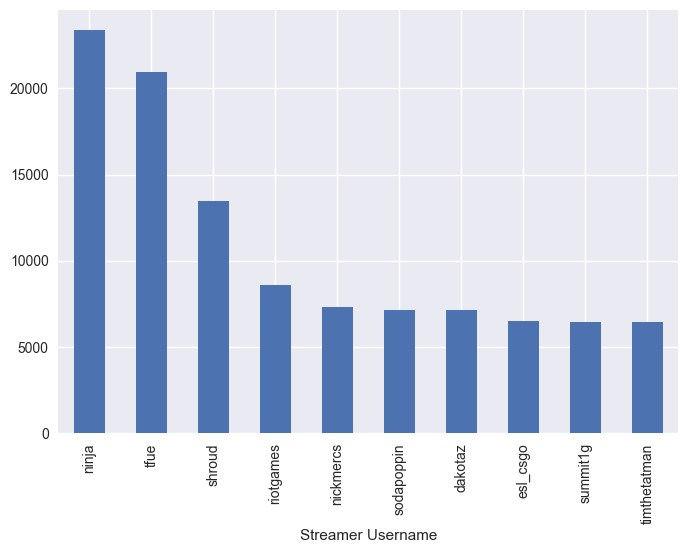

In [5]:
twitchdf["Streamer Username"].value_counts()[:10].plot(kind="bar")

In [6]:
len(twitchdf["Streamer Username"].value_counts())

108280

# 1. Predictive Task
- We will build a recommender system that predicts if you will watch a streamer or not (AKA a Twitch streamer recommender).
- First we will prep the data to just user-streamer interactions, 1 if they interacted, 0 if they did not. We will have to generate a dataset of negatives (a dataset of did not interact) ourselves on a 2:1 ratio. This reflects real world scenarios where most users really only watch a handful of streamers while also still being not too computationally expensive.
- To evaluate the model, we will split the data to 80% for training and 20% for testing. Both splits will maintain a 2:1 ratio. The metric we will use to evaluate the model is Precision@K and Recall@K.
- Our baseline will be recommending globally popular streamers 
- The model we plan to use to improve the baseline is weighted matrix factorization (weighted by % of total time on Twitch spent on watching this streamer)

## Data Prep
First we will extract the proportion of time each user spent watching each streamer

In [5]:
# For each userID and streamer username pair, add a new column 'proportion of time'
twitchdf['total_watch_time'] = twitchdf['UserID'].map(twitchdf.groupby('UserID').apply(lambda x: (x['Time Stop'] - x['Time Start']).sum()))
twitchdf['watch_time'] = twitchdf['Time Stop'] - twitchdf['Time Start']
twitchdf['proportion_of_time'] = twitchdf['watch_time'] / twitchdf['total_watch_time']
twitchdf['watch_minutes'] = twitchdf['watch_time'] * 10  # each unit is 10 minutes
twitchdf.head()

C:\Users\jerem\AppData\Local\Temp\ipykernel_27456\3156750793.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  twitchdf['total_watch_time'] = twitchdf['UserID'].map(twitchdf.groupby('UserID').apply(lambda x: (x['Time Stop'] - x['Time Start']).sum()))


,UserID,StreamID,Streamer Username,Time Start,Time Stop,total_watch_time,watch_time,proportion_of_time,watch_minutes
0,1,33842865744,mithrain,154,156,117,2,0.017094,20
1,1,33846768288,alptv,166,169,117,3,0.025641,30
2,1,33886469056,mithrain,587,588,117,1,0.008547,10
3,1,33887624992,wtcn,589,591,117,2,0.017094,20
4,1,33890145056,jrokezftw,591,594,117,3,0.025641,30


In [6]:
# Sum both proportion_of_time and actual watch minutes for each user/streamer pair
twitchdf_grouped = (
    twitchdf.groupby(['UserID', 'Streamer Username'])
    .agg({
        'proportion_of_time': 'sum',
        'watch_minutes': 'sum'
    })
    .reset_index()
 )
twitchdf_grouped['interaction_weight'] = np.log1p(twitchdf_grouped['watch_minutes']) * (
    1.0 + 0.5 * twitchdf_grouped['proportion_of_time']
 )
twitchdf_grouped.head()

,UserID,Streamer Username,proportion_of_time,watch_minutes,interaction_weight
0,1,alptv,0.025641,30,3.478013
1,1,berkriptepe,0.025641,30,3.478013
2,1,elraenn,0.017094,20,3.070544
3,1,eraymaskulen,0.008547,10,2.408143
4,1,esl_csgo,0.008547,10,2.408143


In [7]:
# Filter to users/items with sufficient history for modeling
min_user_interactions = 3
min_streamer_viewers = 25
user_counts = twitchdf_grouped.groupby('UserID').size()
streamer_counts = twitchdf_grouped.groupby('Streamer Username').size()
eligible_users = user_counts[user_counts >= min_user_interactions].index
eligible_streamers = streamer_counts[streamer_counts >= min_streamer_viewers].index
model_df = twitchdf_grouped[
    twitchdf_grouped['UserID'].isin(eligible_users) &
    twitchdf_grouped['Streamer Username'].isin(eligible_streamers)
].copy()
print(f"Original interactions: {twitchdf_grouped.shape[0]:,}")
print(f"Filtered interactions: {model_df.shape[0]:,}")
print(f"Users kept: {model_df['UserID'].nunique():,} / {twitchdf_grouped['UserID'].nunique():,}")
print(f"Streamers kept: {model_df['Streamer Username'].nunique():,} / {twitchdf_grouped['Streamer Username'].nunique():,}")
model_df.head()

Original interactions: 748,919
Filtered interactions: 487,129
Users kept: 46,269 / 50,000
Streamers kept: 3,984 / 108,280


,UserID,Streamer Username,proportion_of_time,watch_minutes,interaction_weight
0,1,alptv,0.025641,30,3.478013
1,1,berkriptepe,0.025641,30,3.478013
2,1,elraenn,0.017094,20,3.070544
4,1,esl_csgo,0.008547,10,2.408143
5,1,grimnax,0.051282,60,4.216281


## EDA
Now we can perform some exploratory data analysis on it

<Axes: title={'center': 'Top 10 Streamers by Number of Unique Viewers'}, xlabel='Streamer Username'>

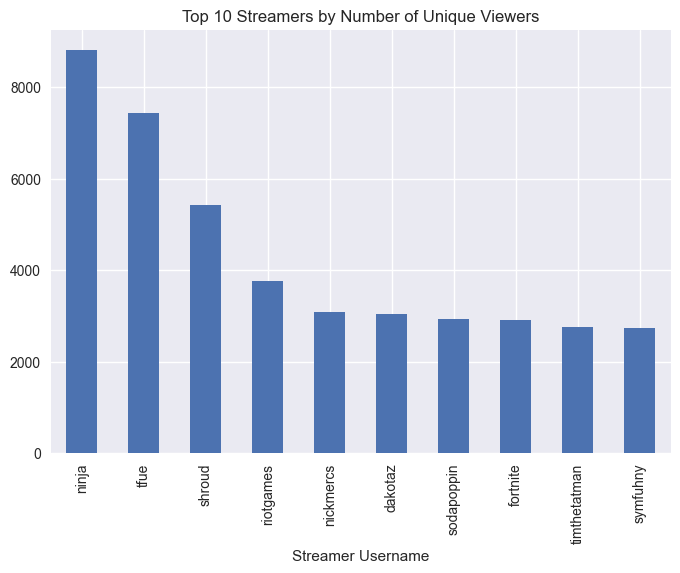

In [9]:
twitchdf_grouped['Streamer Username'].value_counts()[:10].plot(kind="bar", title="Top 10 Streamers by Number of Unique Viewers")

<Axes: title={'center': 'Top 10 Streamers by Total Proportion of Time Watched'}, xlabel='Streamer Username'>

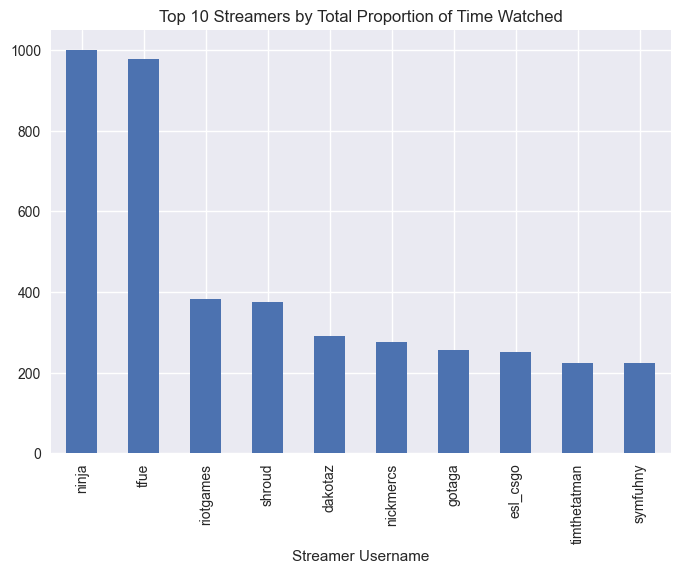

In [10]:
twitchdf_grouped.groupby('Streamer Username')['proportion_of_time'].sum().sort_values(ascending=False)[:10].plot(kind="bar", title="Top 10 Streamers by Total Proportion of Time Watched")

These 2 graphs show the most popular streamers by %of time spent by users and total unique viewers. We'll use the unique viewers top 10 for our baseline model. Our MF model will likely still incorporate popularity for cold start problems.

<Axes: title={'center': 'Distribution of Proportion of Time Watched'}, ylabel='Frequency'>

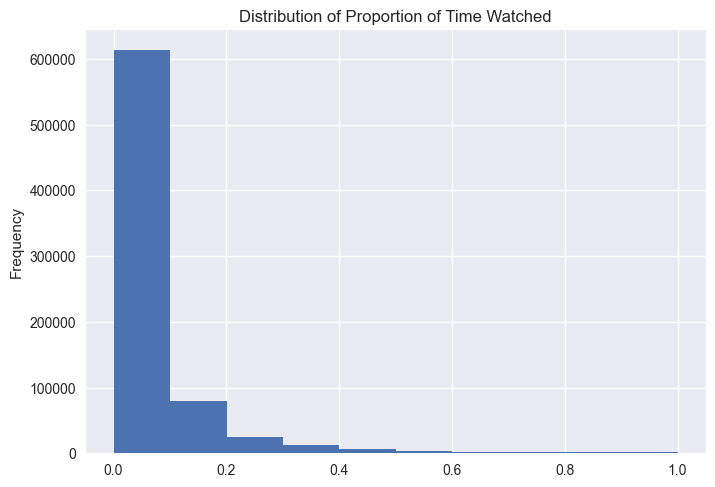

In [11]:
twitchdf_grouped['proportion_of_time'].plot(kind="hist", title="Distribution of Proportion of Time Watched")

In [8]:
user_activity = model_df.groupby('UserID').size()
streamer_popularity = model_df.groupby('Streamer Username').size()
print("User interactions per user -> mean: {:.2f}, median: {}, 95th pct: {}".format(
    user_activity.mean(),
    int(user_activity.median()),
    int(user_activity.quantile(0.95))
) )
print("Streamers per user covering 80% interactions: {:.2f}".format(
    user_activity.quantile(0.80)
) )
print("Streamer unique viewers -> mean: {:.2f}, median: {}, 95th pct: {}".format(
    streamer_popularity.mean(),
    int(streamer_popularity.median()),
    int(streamer_popularity.quantile(0.95))
) )
print(f"Users with <=5 interactions: {(user_activity <= 5).mean()*100:.1f}%")
print(f"Streamers with <=20 unique viewers: {(streamer_popularity <= 20).mean()*100:.1f}%")

User interactions per user -> mean: 10.53, median: 7, 95th pct: 31
Streamers per user covering 80% interactions: 16.00
Streamer unique viewers -> mean: 122.27, median: 53, 95th pct: 388
Users with <=5 interactions: 39.4%
Streamers with <=20 unique viewers: 0.0%


This graph shows that most users don't spend more than 10% of their time on Twitch on only one streamer. In other words, the users in our dataset watch a good variety of streamers, which is good to train our recommender system

## Implicit ALS Recommender
To improve recommendation quality we now train an implicit Alternating Least Squares (ALS) model. We work directly with the user-streamer interaction matrix (weighted by the proportion of time spent with each streamer) and evaluate ranking metrics on a user-level train/test split.

In [8]:
# Build sparse user-item matrix (users x streamers) using log-scaled watch-time weights
user_ids = np.sort(model_df['UserID'].unique())
streamer_ids = np.sort(model_df['Streamer Username'].unique())
user_id_map = {uid: idx for idx, uid in enumerate(user_ids)}
item_id_map = {sid: idx for idx, sid in enumerate(streamer_ids)}
idx_to_user = {idx: uid for uid, idx in user_id_map.items()}
idx_to_item = {idx: sid for sid, idx in item_id_map.items()}
row_idx = model_df['UserID'].map(user_id_map).values
col_idx = model_df['Streamer Username'].map(item_id_map).values
values = model_df['interaction_weight'].astype(float).values
user_item = sparse.coo_matrix((values, (row_idx, col_idx)), shape=(len(user_ids), len(streamer_ids))).tocsr()
density = user_item.nnz / float(user_item.shape[0] * user_item.shape[1])
print(f"User-item matrix shape: {user_item.shape}")
print(f"Non-zero interactions: {user_item.nnz:,}")
print(f"Matrix density: {density:.8f}")
print(f"Weight stats -> min: {values.min():.4f}, median: {np.median(values):.4f}, max: {values.max():.4f}")

User-item matrix shape: (46269, 3984)
Non-zero interactions: 487,129
Matrix density: 0.00264262
Weight stats -> min: 2.3988, median: 3.2787, max: 12.6085


### Train/Test Split and ALS Training
We remove 20% of each user's interactions for evaluation, transform weights into confidence scores, and train the implicit ALS model on the remaining data.

In [9]:
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import train_test_split
train_user_items, test_user_items = train_test_split(
    user_item.tocoo(),
    train_percentage=0.8,
    random_state=42
)
alpha = 60.0
train_weighted = bm25_weight(train_user_items.copy().astype('double'), K1=1.2, B=0.75)
confidence = train_weighted.multiply(alpha)
confidence.data += 1.0
print(f"Train nnz: {train_user_items.nnz:,} | Test nnz: {test_user_items.nnz:,}")
print(f"confidence matrix shape: {confidence.shape}")
model = AlternatingLeastSquares(
    factors=120,
    regularization=0.01,
    iterations=70,
    use_gpu=False,
    random_state=42
)
model.fit(confidence)
print("ALS training complete!")

c:\Users\jerem\Miniconda3\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
c:\Users\jerem\Miniconda3\lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.004010677337646484 seconds
  warnings.warn(


Train nnz: 389,964 | Test nnz: 97,165
confidence matrix shape: (46269, 3984)


100%|██████████| 70/70 [00:09<00:00,  7.73it/s]

ALS training complete!


In [10]:
# Train a Bayesian Personalized Ranking (BPR) model on binarized interactions
from implicit.bpr import BayesianPersonalizedRanking
from implicit.lmf import LogisticMatrixFactorization
train_user_binary = train_user_items.copy().astype(np.float32)
train_user_binary.data = np.ones_like(train_user_binary.data)
print(f"Binary train matrix nnz: {train_user_binary.nnz:,}")
bpr_model = BayesianPersonalizedRanking(
    factors=200,
    learning_rate=0.05,
    regularization=0.002,
    iterations=100,
    random_state=42
)
bpr_model.fit(train_user_binary, show_progress=True)
print("BPR training complete!")


lmf_model = LogisticMatrixFactorization(
    factors=120,
    learning_rate=0.8,
    regularization=0.001,
    iterations=80,
    neg_prop=5,
    random_state=42
)
lmf_model.fit(train_user_binary, show_progress=True)
print("Logistic MF training complete!")

Binary train matrix nnz: 389,964


100%|██████████| 100/100 [00:05<00:00, 16.68it/s, train_auc=99.59%, skipped=2.54%]



BPR training complete!


100%|██████████| 80/80 [00:20<00:00,  3.88it/s]

Logistic MF training complete!


### Ranking Metrics
We benchmark three recommenders on held-out interactions: a global popularity baseline, the ALS model, and a hybrid that boosts ALS scores with streamer popularity. Metrics are Precision@K, Recall@K, and F1@K (higher is better).

In [11]:
# Popularity statistics from training interactions
popularity_scores = np.asarray(train_user_items.sum(axis=0)).ravel()
popular_item_indices = np.argsort(-popularity_scores)
popularity_norm = (popularity_scores - popularity_scores.min()) / (popularity_scores.max() - popularity_scores.min() + 1e-9)
print(f"Non-zero popularity entries: {(popularity_scores > 0).sum():,}")
print(f"Top streamer (training): {idx_to_item[popular_item_indices[0]]}")

Non-zero popularity entries: 3,984
Top streamer (training): ninja


In [12]:
print(f"User factors shape: {model.user_factors.shape}")
print(f"Item factors shape: {model.item_factors.shape}")

User factors shape: (46269, 120)
Item factors shape: (3984, 120)


In [ ]:
def compute_ranking_metrics(predict_fn, test_mat, ks=(5, 10, 20)) -> pd.DataFrame:
    test_csr = test_mat.tocsr()
    max_k = max(ks)
    precision_logs = {k: [] for k in ks}
    recall_logs = {k: [] for k in ks}
    hit_logs = {k: [] for k in ks}
    evaluated_users = 0
    for user_idx in range(test_csr.shape[0]):
        start, end = test_csr.indptr[user_idx], test_csr.indptr[user_idx + 1]
        if start == end:
            continue
        rec_indices = predict_fn(user_idx, max_k)
        if rec_indices is None:
            continue
        rec_indices = np.array(rec_indices, dtype=np.int64)
        if rec_indices.size == 0:
            continue
        evaluated_users += 1
        test_items = set(test_csr.indices[start:end])
        for k in ks:
            topk = rec_indices[:k]
            hits = sum(1 for item in topk if item in test_items)
            precision_logs[k].append(hits / k)
            recall_logs[k].append(hits / len(test_items))
            hit_logs[k].append(1.0 if hits > 0 else 0.0)
    rows = []
    for k in ks:
        precision = float(np.mean(precision_logs[k])) if precision_logs[k] else 0.0
        recall = float(np.mean(recall_logs[k])) if recall_logs[k] else 0.0
        hit_rate = float(np.mean(hit_logs[k])) if hit_logs[k] else 0.0
        f1 = 0.0 if (precision + recall) == 0 else 2 * (precision * recall) / (precision + recall)
        rows.append({"K": k, "Precision": precision, "Recall": recall, "HitRate": hit_rate, "F1": f1, "Users": evaluated_users})
    return pd.DataFrame(rows)

def popularity_predict(user_idx: int, top_n: int) -> np.ndarray:
    return popular_item_indices[:top_n]

def als_predict(user_idx: int, top_n: int) -> np.ndarray | None:
    user_history = train_user_items[user_idx]
    if user_history.nnz == 0:
        return None
    rec_indices, _ = model.recommend(user_idx, user_history, N=top_n, filter_already_liked_items=True)
    return rec_indices

def bpr_predict(user_idx: int, top_n: int) -> np.ndarray | None:
    if user_idx >= train_user_binary.shape[0]:
        return None
    user_history = train_user_binary[user_idx]
    if user_history.nnz == 0:
        return None
    rec_indices, _ = bpr_model.recommend(user_idx, user_history, N=top_n, filter_already_liked_items=True)
    return rec_indices

def lmf_predict(user_idx: int, top_n: int) -> np.ndarray | None:
    if user_idx >= train_user_binary.shape[0]:
        return None
    user_history = train_user_binary[user_idx]
    if user_history.nnz == 0:
        return None
    rec_indices, _ = lmf_model.recommend(user_idx, user_history, N=top_n, filter_already_liked_items=True)
    return rec_indices

def hybrid_predict(user_idx: int, top_n: int, pop_weight: float = 0.3, extra: int = 200) -> np.ndarray | None:
    user_history = train_user_items[user_idx]
    if user_history.nnz == 0:
        return None
    candidate_n = min(top_n + extra, model.item_factors.shape[0])
    rec_indices, scores = model.recommend(user_idx, user_history, N=candidate_n, filter_already_liked_items=True)
    boosted_scores = scores + pop_weight * popularity_norm[rec_indices]
    order = np.argsort(-boosted_scores)
    return rec_indices[order][:top_n]

def _normalize_scores(scores: np.ndarray) -> np.ndarray:
    if scores.size == 0:
        return scores
    std = scores.std()
    if std < 1e-9:
        denom = np.abs(scores).max() + 1e-9
        return scores / denom if denom > 0 else scores
    return (scores - scores.mean()) / (std + 1e-9)

def ensemble_predict(
    user_idx: int,
    top_n: int,
    extra: int = 200,
    als_weight: float = 0.6,
    bpr_weight: float = 0.25,
    lmf_weight: float = 0.05,
    pop_weight: float = 0.1
) -> np.ndarray | None:
    user_history = train_user_items[user_idx]
    if user_history.nnz == 0:
        return None
    candidate_n = min(top_n + extra, model.item_factors.shape[0])
    score_map = defaultdict(float)

    def add_scores(indices, scores, weight):
        if indices is None or len(indices) == 0 or weight == 0:
            return
        norm_scores = _normalize_scores(scores)
        for idx, score in zip(indices, norm_scores):
            score_map[idx] += weight * score

    als_indices, als_scores = model.recommend(
        user_idx, user_history, N=candidate_n, filter_already_liked_items=True
    )
    add_scores(als_indices, als_scores, als_weight)

    bpr_history = train_user_binary[user_idx]
    if bpr_history.nnz > 0:
        bpr_indices, bpr_scores = bpr_model.recommend(
            user_idx,
            bpr_history,
            N=candidate_n,
            filter_already_liked_items=True
        )
        add_scores(bpr_indices, bpr_scores, bpr_weight)

    if bpr_history.nnz > 0:
        lmf_indices, lmf_scores = lmf_model.recommend(
            user_idx,
            bpr_history,
            N=candidate_n,
            filter_already_liked_items=True
        )
        add_scores(lmf_indices, lmf_scores, lmf_weight)

    train_items = set(user_history.indices)
    added = 0
    for idx in popular_item_indices:
        if idx in train_items:
            continue
        score_map[idx] += pop_weight * popularity_norm[idx]
        added += 1
        if added >= candidate_n:
            break

    if not score_map:
        return None
    ranked = sorted(score_map.items(), key=lambda kv: kv[1], reverse=True)
    return np.array([idx for idx, _ in ranked[:top_n]], dtype=np.int64)

def evaluate_model(name: str, predict_fn) -> pd.DataFrame:
    metrics = compute_ranking_metrics(predict_fn, test_user_items)
    metrics.insert(0, "Model", name)
    print(f"{name} evaluated on {metrics['Users'].iloc[0]} users")
    return metrics

print(f"train_user_items shape: {train_user_items.shape}, train_user_binary shape: {train_user_binary.shape}")


































































































results = []
results.append(evaluate_model("Popularity", popularity_predict))
results.append(evaluate_model("ALS (log-watch)", als_predict))
results.append(evaluate_model("BPR (binary)", bpr_predict))
results.append(evaluate_model("Logistic MF", lmf_predict))
results.append(evaluate_model("Hybrid ALS+pop", lambda user_idx, top_n: hybrid_predict(user_idx, top_n, pop_weight=0.3, extra=200)))
results.append(evaluate_model("Ensemble (ALS+BPR+pop)", lambda user_idx, top_n: ensemble_predict(user_idx, top_n)))
comparison_df = pd.concat(results, ignore_index=True)
print("\nRanking metrics comparison:")
display(comparison_df)

train_user_items shape: (46269, 3984), train_user_binary shape: (46269, 3984)
Popularity evaluated on 34307 users
Popularity evaluated on 34307 users
ALS (log-watch) evaluated on 33692 users
ALS (log-watch) evaluated on 33692 users
BPR (binary) evaluated on 33692 users
BPR (binary) evaluated on 33692 users
Logistic MF evaluated on 33692 users
Logistic MF evaluated on 33692 users
Hybrid ALS+pop evaluated on 33692 users
Hybrid ALS+pop evaluated on 33692 users
Ensemble (ALS+BPR+pop) evaluated on 33692 users

Ranking metrics comparison:
Ensemble (ALS+BPR+pop) evaluated on 33692 users

Ranking metrics comparison:


,Model,K,Precision,Recall,HitRate,F1,Users
0,Popularity,5,0.033398,0.067510,0.150727,0.044689,34307
1,Popularity,10,0.025018,0.099110,0.208471,0.039952,34307
2,Popularity,20,0.018611,0.142342,0.278165,0.032919,34307
3,ALS (log-watch),5,0.138793,0.278589,0.508578,0.185279,33692
4,ALS (log-watch),10,0.102986,0.397361,0.638134,0.163577,33692
5,ALS (log-watch),20,0.070610,0.524804,0.744717,0.124473,33692
6,BPR (binary),5,0.082465,0.165990,0.328980,0.110188,33692
7,BPR (binary),10,0.063306,0.247999,0.446130,0.100864,33692
8,BPR (binary),20,0.046570,0.354818,0.571352,0.082334,33692
9,Logistic MF,5,0.054494,0.085003,0.207646,0.066412,33692


### Sample Recommendations
Verify the qualitative behavior by inspecting predictions for a user who retains at least three held-out interactions.

In [14]:
for k in (5, 10, 20):
    subset = comparison_df[comparison_df['K'] == k][['Model', 'Precision', 'Recall', 'HitRate', 'F1']]
    print(f"\nMetrics at K={k}")
    print(subset.to_string(index=False))


Metrics at K=5
                 Model  Precision   Recall  HitRate       F1
            Popularity   0.033398 0.067510 0.150727 0.044689
       ALS (log-watch)   0.138793 0.278589 0.508578 0.185279
          BPR (binary)   0.082465 0.165990 0.328980 0.110188
           Logistic MF   0.054494 0.085003 0.207646 0.066412
        Hybrid ALS+pop   0.146907 0.294683 0.531165 0.196069
Ensemble (ALS+BPR+pop)   0.144064 0.286661 0.519025 0.191758

Metrics at K=10
                 Model  Precision   Recall  HitRate       F1
            Popularity   0.025018 0.099110 0.208471 0.039952
       ALS (log-watch)   0.102986 0.397361 0.638134 0.163577
          BPR (binary)   0.063306 0.247999 0.446130 0.100864
           Logistic MF   0.042063 0.132281 0.286240 0.063830
        Hybrid ALS+pop   0.107370 0.414425 0.657307 0.170552
Ensemble (ALS+BPR+pop)   0.105043 0.403793 0.643892 0.166716

Metrics at K=20
                 Model  Precision   Recall  HitRate       F1
            Popularity   0.018611 0

In [15]:
from datetime import datetime
import json
from pathlib import Path

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "als_model.npz"
model.save(str(model_path))

popularity_path = artifacts_dir / "popularity_norm.npy"
np.save(popularity_path, popularity_norm.astype(np.float32))

train_user_items_csr = train_user_items.tocsr()
history_lookup = {}
for row_idx in range(train_user_items_csr.shape[0]):
    start = train_user_items_csr.indptr[row_idx]
    end = train_user_items_csr.indptr[row_idx + 1]
    watched = train_user_items_csr.indices[start:end].astype(int).tolist()
    history_lookup[str(idx_to_user[row_idx])] = watched

history_path = artifacts_dir / "user_history.json"
with history_path.open("w", encoding="utf-8") as fp:
    json.dump(history_lookup, fp)

lookup_payload = {
    "user_id_map": {str(uid): int(idx) for uid, idx in user_id_map.items()},
    "idx_to_user": {str(idx): int(uid) for idx, uid in idx_to_user.items()},
    "item_id_map": item_id_map,
    "idx_to_item": {str(k): v for k, v in idx_to_item.items()},
    "model_params": {
        "factors": int(model.factors),
        "regularization": float(model.regularization),
        "iterations": int(model.iterations),
        "alpha": float(alpha),
        "bm25_K1": 1.2,
        "bm25_B": 0.75
    },
    "generated_at": datetime.utcnow().isoformat() + "Z",
    "artifacts": {
        "model": model_path.name,
        "popularity_norm": popularity_path.name,
        "user_history": history_path.name
    }
}

lookup_path = artifacts_dir / "lookup.json"
with lookup_path.open("w", encoding="utf-8") as fp:
    json.dump(lookup_payload, fp)

print(f"Saved ALS model to {model_path}")
print(f"Saved popularity weights to {popularity_path}")
print(f"Saved user history to {history_path}")
print(f"Saved lookup metadata to {lookup_path}")

Saved ALS model to artifacts\als_model.npz
Saved popularity weights to artifacts\popularity_norm.npy
Saved user history to artifacts\user_history.json
Saved lookup metadata to artifacts\lookup.json


In [78]:
def recommend_for_user(user_id: int, strategy: str = "als", top_n: int = 10):
    if user_id not in user_id_map:
        raise ValueError("Unknown user id")
    internal_id = user_id_map[user_id]
    if strategy == "popularity":
        rec_indices = popularity_predict(internal_id, top_n)
    elif strategy == "bpr":
        rec_indices = bpr_predict(internal_id, top_n)
    elif strategy == "lmf":
        rec_indices = lmf_predict(internal_id, top_n)
    elif strategy == "hybrid":
        rec_indices = hybrid_predict(internal_id, top_n)
    elif strategy == "ensemble":
        rec_indices = ensemble_predict(internal_id, top_n)
    else:
        rec_indices = als_predict(internal_id, top_n)
    if rec_indices is None or len(rec_indices) == 0:
        print("User has no training interactions; cannot generate recommendations.")
        return
    rec_items = [idx_to_item[idx] for idx in rec_indices]
    print(f"Top {top_n} {strategy.upper()} recommendations for user {user_id}:")
    for rank, item in enumerate(rec_items, 1):
        print(f"{rank:2d}. {item}")

random_user = random.choice(list(user_id_map.keys()))
print("Showing recommendations for the same user across strategies to compare:")
print(f"Random user id: {random_user}")
for strategy in ["popularity", "als", "bpr", "lmf", "hybrid", "ensemble"]:
    print("-" * 60)
    recommend_for_user(random_user, strategy=strategy, top_n=10)

Showing recommendations for the same user across strategies to compare:
Random user id: 15104
------------------------------------------------------------
Top 10 POPULARITY recommendations for user 15104:
 1. ninja
 2. tfue
 3. shroud
 4. riotgames
 5. nickmercs
 6. sodapoppin
 7. dakotaz
 8. timthetatman
 9. symfuhny
10. esl_csgo
------------------------------------------------------------
Top 10 ALS recommendations for user 15104:
 1. tfblade
 2. toyzttv
 3. asiagodtonegg3be0
 4. c9sneaky
 5. relaxing234
 6. bebelolz
 7. faker
 8. imaqtpie
 9. lpl
10. gosu
------------------------------------------------------------
Top 10 BPR recommendations for user 15104:
 1. lpl
 2. faker
 3. toyzttv
 4. lck
 5. t1_teddy
 6. lol_peanut
 7. rainbrain
 8. godjj
 9. lol_woolf
10. lol_ambition
------------------------------------------------------------
Top 10 LMF recommendations for user 15104:
 1. tfue
 2. amouranth
 3. mongraal
 4. gaules
 5. ninja
 6. noway4u_sir
 7. drdisrespect
 8. mrfreshasian

### Takeaways
- ALS handles the implicit feedback setting natively and improves Precision@K/Recall@K without manually synthesizing negative samples.
- Tuning the number of latent factors, the confidence weight `alpha`, or adding side features (e.g., streamer genres) are natural next steps for even better personalization.